# Notebook 2: Comprehensive EDA & Statistical Analysis
## Deep Exploration of All 99 HMDA Features

**Objective:** Systematically analyze every column in the HMDA dataset to understand distributions, relationships with the target (loan denial), detect anomalies, and identify which features carry predictive signal for our ML models.

## Section 1: Setup & Data Loading

**WHY load from Parquet instead of CSV?**
We saved Parquet in Notebook 1 specifically for this - it loads 3-5x faster than CSV because:
- No schema inference needed (types are embedded in Parquet metadata)
- Columnar format means we can read only the columns we need
- Compressed storage means less disk I/O

In [3]:
# ============================================================
# Imports
# ============================================================

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.sql.window import Window

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import json
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")
print("Imports loaded.")

Imports loaded.


In [4]:
# ============================================================
# Initialize Spark & Load Data
# ============================================================

spark = (SparkSession.builder
    .appName("HMDA_2023_EDA")
    .master("local[*]")
    .config("spark.driver.memory", "8g")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

# Load from Parquet (created in Notebook 1)
PARQUET_PATH = "../data/processed/hmda_2023.parquet"
df = spark.read.parquet(PARQUET_PATH)

# Load schema for reference
SCHEMA_PATH = "../data/schemas/hmda_schema.json"
with open(SCHEMA_PATH, "r") as f:
    schema = json.load(f)

total_rows = df.count()
print(f"Dataset loaded: {total_rows:,} rows x {len(df.columns)} columns")

# Cache the DataFrame
# WHY cache? Without it, Spark re-reads Parquet from disk for EVERY query.
# With cache, it stays in memory after the first read.
df.cache()
df.count()  
print("DataFrame cached in memory.")

Dataset loaded: 11,483,889 rows x 99 columns


26/03/02 00:27:59 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


DataFrame cached in memory.


In [5]:
# ============================================================
# Define Column Groups for Systematic Analysis
# ============================================================

NUMERIC_CONTINUOUS = schema["expected_dtypes"]["numeric_continuous"]
CATEGORICAL_NOMINAL = schema["expected_dtypes"]["categorical_nominal"]
CATEGORICAL_ORDINAL = schema["expected_dtypes"]["categorical_ordinal"]
LEAKAGE_COLS = schema["leakage_columns"]["columns"]

print(f"Numeric continuous:   {len(NUMERIC_CONTINUOUS)} columns")
print(f"Categorical nominal:  {len(CATEGORICAL_NOMINAL)} columns")
print(f"Categorical ordinal:  {len(CATEGORICAL_ORDINAL)} columns")
print(f"Leakage (to exclude): {len(LEAKAGE_COLS)} columns")
print(f"\nLeakage columns: {LEAKAGE_COLS}")

Numeric continuous:   22 columns
Categorical nominal:  69 columns
Categorical ordinal:  6 columns
Leakage (to exclude): 12 columns

Leakage columns: ['denial_reason_1', 'denial_reason_2', 'denial_reason_3', 'denial_reason_4', 'purchaser_type', 'rate_spread', 'total_loan_costs', 'total_points_and_fees', 'origination_charges', 'discount_points', 'lender_credits', 'prepayment_penalty_term']


## Section 2: Univariate Analysis - Numeric Features

**Key statistics we compute:**
- **Mean/Median**: If mean >> median, distribution is right-skewed (common in financial data)
- **Std Dev**: Measure of spread - high std dev means high variability
- **Skewness**: 0 = symmetric, >1 = right-skewed, <-1 = left-skewed
- **Kurtosis**: Measures tail heaviness - high kurtosis = more outliers
- **IQR & Outlier bounds**: Using 1.5*IQR rule to flag extreme values

In [6]:
# ============================================================
# Descriptive Statistics for ALL Numeric Columns
# ============================================================

# First, get basic stats using describe()
numeric_cols_in_df = [c for c in NUMERIC_CONTINUOUS if c in df.columns]

print("=" * 100)
print(f"DESCRIPTIVE STATISTICS FOR {len(numeric_cols_in_df)} NUMERIC COLUMNS")
print("=" * 100)

# Compute comprehensive stats in one pass using agg()

agg_exprs = []
for col in numeric_cols_in_df:
    agg_exprs.extend([
        F.count(F.when(F.col(col).isNotNull(), True)).alias(f"{col}__count"),
        F.mean(col).alias(f"{col}__mean"),
        F.stddev(col).alias(f"{col}__stddev"),
        F.min(col).alias(f"{col}__min"),
        F.max(col).alias(f"{col}__max"),
        F.skewness(col).alias(f"{col}__skew"),
        F.kurtosis(col).alias(f"{col}__kurtosis"),
    ])

stats_row = df.agg(*agg_exprs).collect()[0]

# Get approximate quartiles (P25, median, P75) for IQR calculation
quantiles = {}
for col in numeric_cols_in_df:
    try:
        q = df.approxQuantile(col, [0.25, 0.5, 0.75], 0.01)  # 1% relative error
        quantiles[col] = q if len(q) == 3 else [None, None, None]
    except:
        quantiles[col] = [None, None, None]

# Display results
print(f"{'Column':<40} {'Count':>10} {'Mean':>12} {'Median':>12} {'StdDev':>12} {'Skew':>8} {'Kurt':>8} {'Min':>12} {'Max':>12}")
print("-" * 140)

numeric_summary = []
for col in numeric_cols_in_df:
    cnt = stats_row[f"{col}__count"]
    mean = stats_row[f"{col}__mean"]
    std = stats_row[f"{col}__stddev"]
    mn = stats_row[f"{col}__min"]
    mx = stats_row[f"{col}__max"]
    skew = stats_row[f"{col}__skew"]
    kurt = stats_row[f"{col}__kurtosis"]
    q25, med, q75 = quantiles.get(col, [None, None, None])
    
    numeric_summary.append({
        "column": col, "count": cnt, "mean": mean, "median": med,
        "stddev": std, "min": mn, "max": mx, "skew": skew, "kurtosis": kurt,
        "q25": q25, "q75": q75
    })
    
    # Format for display
    mean_s = f"{mean:>12.2f}" if mean is not None else f"{'N/A':>12}"
    med_s = f"{med:>12.2f}" if med is not None else f"{'N/A':>12}"
    std_s = f"{std:>12.2f}" if std is not None else f"{'N/A':>12}"
    skew_s = f"{skew:>8.2f}" if skew is not None else f"{'N/A':>8}"
    kurt_s = f"{kurt:>8.2f}" if kurt is not None else f"{'N/A':>8}"
    
    print(f"  {col:<38} {cnt:>10,} {mean_s} {med_s} {std_s} {skew_s} {kurt_s} {str(mn):>12} {str(mx):>12}")

print("\nKey observations to note:")
print("  - Columns where mean >> median indicate RIGHT SKEW (common in financial data)")
print("  - High kurtosis (>3) means heavy tails = more outliers")
print("  - Columns with count << total_rows have significant missing values")

DESCRIPTIVE STATISTICS FOR 22 NUMERIC COLUMNS


Column                                        Count         Mean       Median       StdDev     Skew     Kurt          Min          Max
--------------------------------------------------------------------------------------------------------------------------------------------
  loan_amount                            11,483,889    327324.11    215000.00  68591732.42  3383.55 11460195.66         5000 232323235000
  combined_loan_to_value_ratio           11,483,889      1374.05          N/A   1907744.47  1754.83 3275287.74        0.001           NA
  interest_rate                          11,483,889         6.90          N/A         1.76     0.18     8.93          0.0           NA
  rate_spread                            11,483,889         0.52          N/A         3.35  -300.36 352997.79       -0.001           NA
  total_loan_costs                       11,483,889      8553.61          N/A   1893168.21  2248.04 5053768.43          0.0           NA
  total_points_and_fees                  

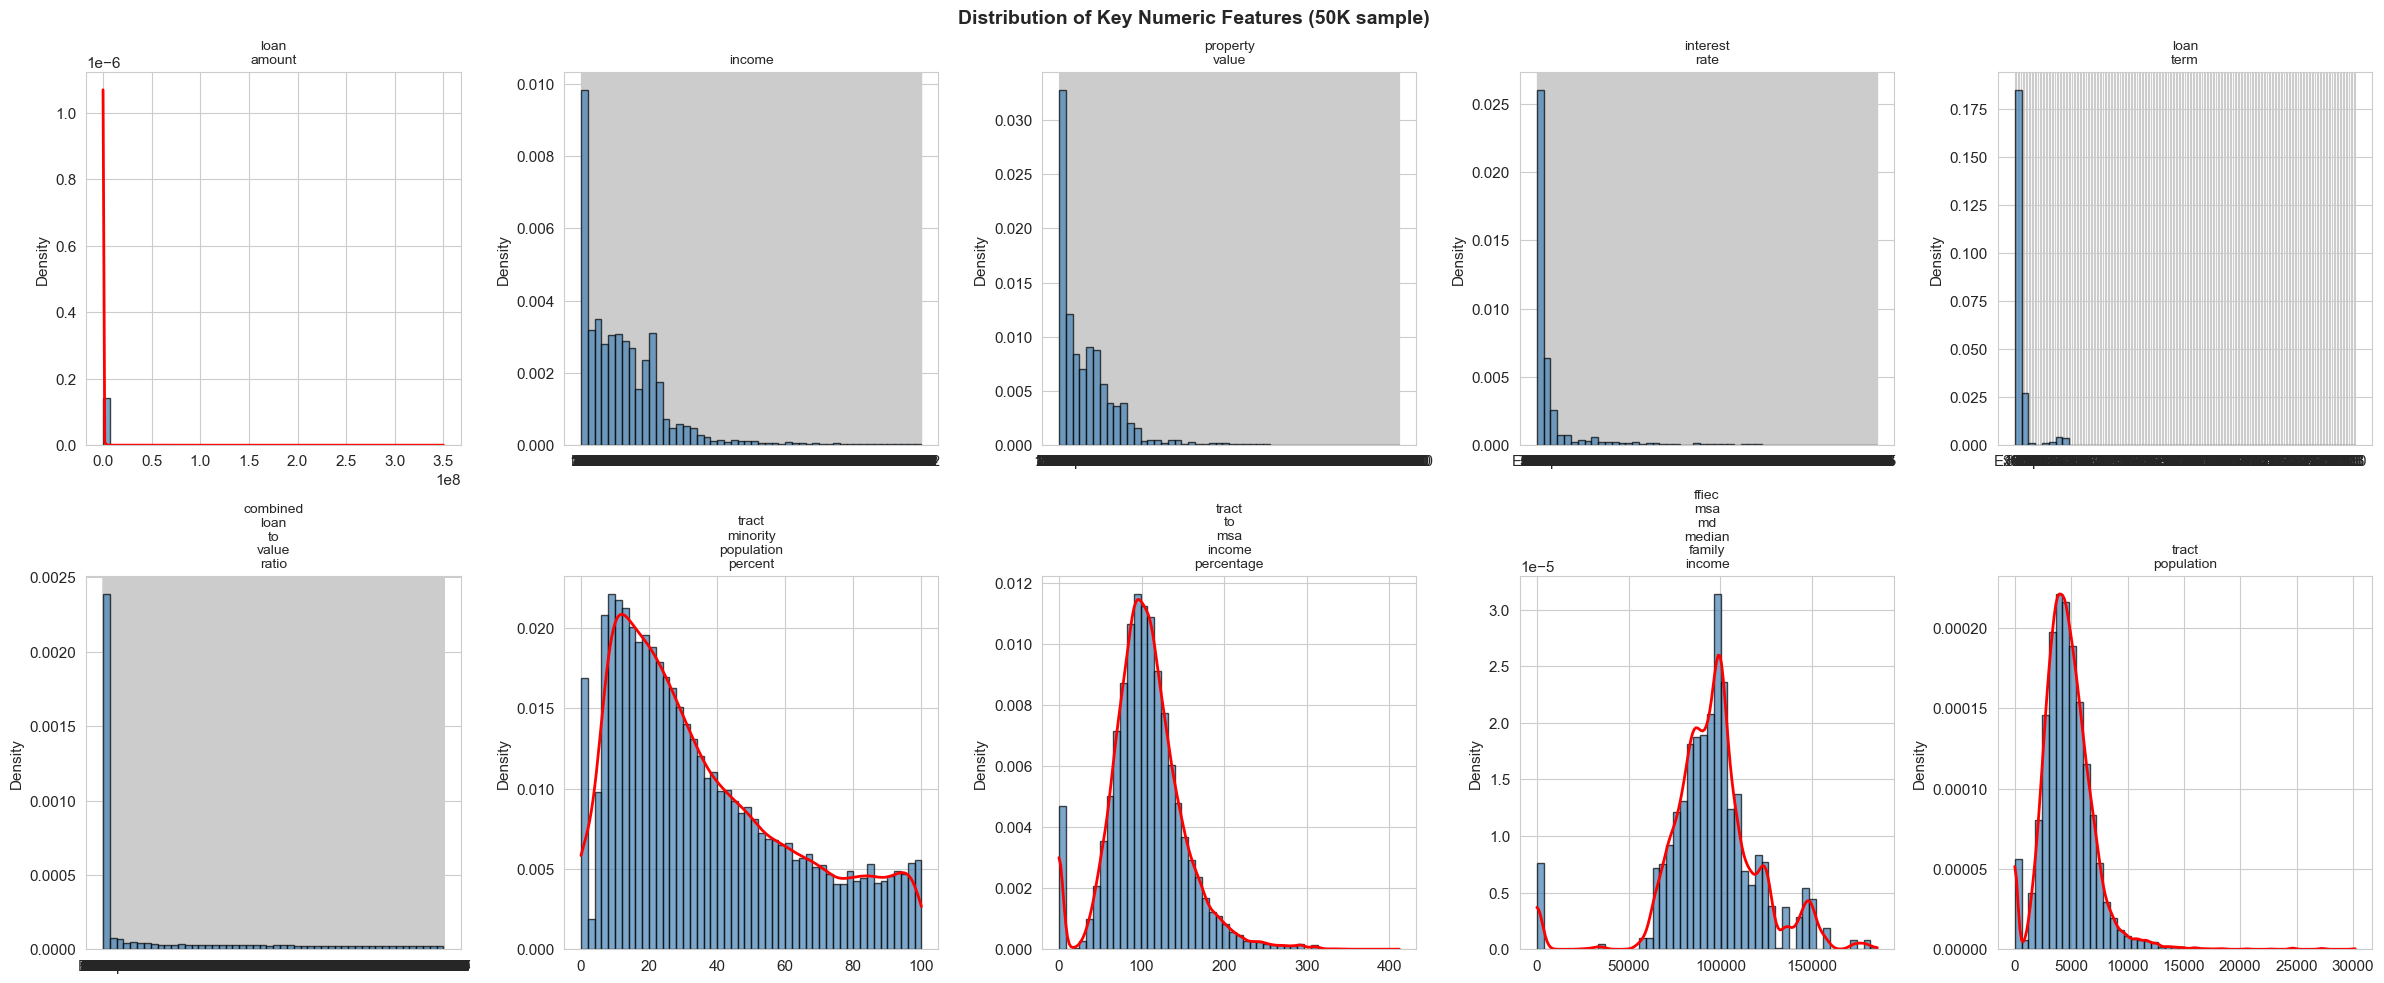

Saved: eda_numeric_distributions.png


In [7]:
# ============================================================
# Distribution Plots for Key Numeric Features
# ============================================================

# Key financial features to plot
key_numeric = [
    "loan_amount", "income", "property_value", "interest_rate",
    "loan_term", "combined_loan_to_value_ratio",
    "tract_minority_population_percent", "tract_to_msa_income_percentage",
    "ffiec_msa_md_median_family_income", "tract_population"
]

sample_pdf = (df
    .select(key_numeric)
    .sample(fraction=50000/total_rows, seed=42)
    .toPandas()
)

fig, axes = plt.subplots(2, 5, figsize=(24, 10))
axes = axes.flatten()

for i, col in enumerate(key_numeric):
    ax = axes[i]
    data = sample_pdf[col].dropna()
    
    if len(data) > 0:
        # Use KDE (Kernel Density Estimation) overlay

        ax.hist(data, bins=50, edgecolor='black', alpha=0.7, density=True, color='steelblue')
        try:
            data_clean = data[np.isfinite(data)]
            if len(data_clean) > 10:
                kde = stats.gaussian_kde(data_clean)
                x_range = np.linspace(data_clean.min(), data_clean.max(), 200)
                ax.plot(x_range, kde(x_range), 'r-', linewidth=2)
        except:
            pass
    
    ax.set_title(col.replace("_", "\n"), fontsize=10)
    ax.set_ylabel("Density")

plt.suptitle("Distribution of Key Numeric Features (50K sample)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../data/processed/eda_numeric_distributions.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eda_numeric_distributions.png")

In [8]:
# ============================================================
#  Outlier Detection for Numeric Features
# ============================================================

print("=" * 90)
print("OUTLIER ANALYSIS (IQR Method)")
print("=" * 90)
print(f"{'Column':<40} {'Q1':>10} {'Q3':>10} {'IQR':>10} {'Lower':>12} {'Upper':>12} {'Outliers':>10} {'Pct':>6}")
print("-" * 100)

outlier_results = []
for col in numeric_cols_in_df:
    q = quantiles.get(col, [None, None, None])
    if q[0] is None or q[2] is None:
        continue
    
    q1, med, q3 = q
    iqr = q3 - q1
    
    if iqr == 0:  # Skip zero-variance columns
        continue
    
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    outlier_count = df.filter(
        (F.col(col) < lower) | (F.col(col) > upper)
    ).count()
    
    pct = (outlier_count / total_rows) * 100
    outlier_results.append({"column": col, "q1": q1, "q3": q3, "iqr": iqr,
                           "lower": lower, "upper": upper, "outlier_count": outlier_count, "pct": pct})
    
    flag = " !!!" if pct > 10 else ""
    print(f"  {col:<38} {q1:>10.1f} {q3:>10.1f} {iqr:>10.1f} {lower:>12.1f} {upper:>12.1f} {outlier_count:>10,} {pct:>5.1f}%{flag}")

print("\n!!! = More than 10% outliers - likely a heavy-tailed distribution, not errors")
print("    For such columns, consider log transformation or winsorization instead of removal")

OUTLIER ANALYSIS (IQR Method)
Column                                           Q1         Q3        IQR        Lower        Upper   Outliers    Pct
----------------------------------------------------------------------------------------------------
  loan_amount                              105000.0   355000.0   250000.0    -270000.0     730000.0    505,406   4.4%
  tract_population                           3321.0     5789.0     2468.0       -381.0       9491.0    302,894   2.6%
  tract_minority_population_percent            14.9       52.5       37.6        -41.4        108.9          0   0.0%
  ffiec_msa_md_median_family_income         83800.0   108200.0    24400.0      47200.0     144800.0    950,216   8.3%
  tract_to_msa_income_percentage               80.4      128.4       48.0          8.3        200.4    776,960   6.8%
  tract_owner_occupied_units                  783.0     1541.0      758.0       -354.0       2678.0    166,115   1.4%
  tract_one_to_four_family_homes           

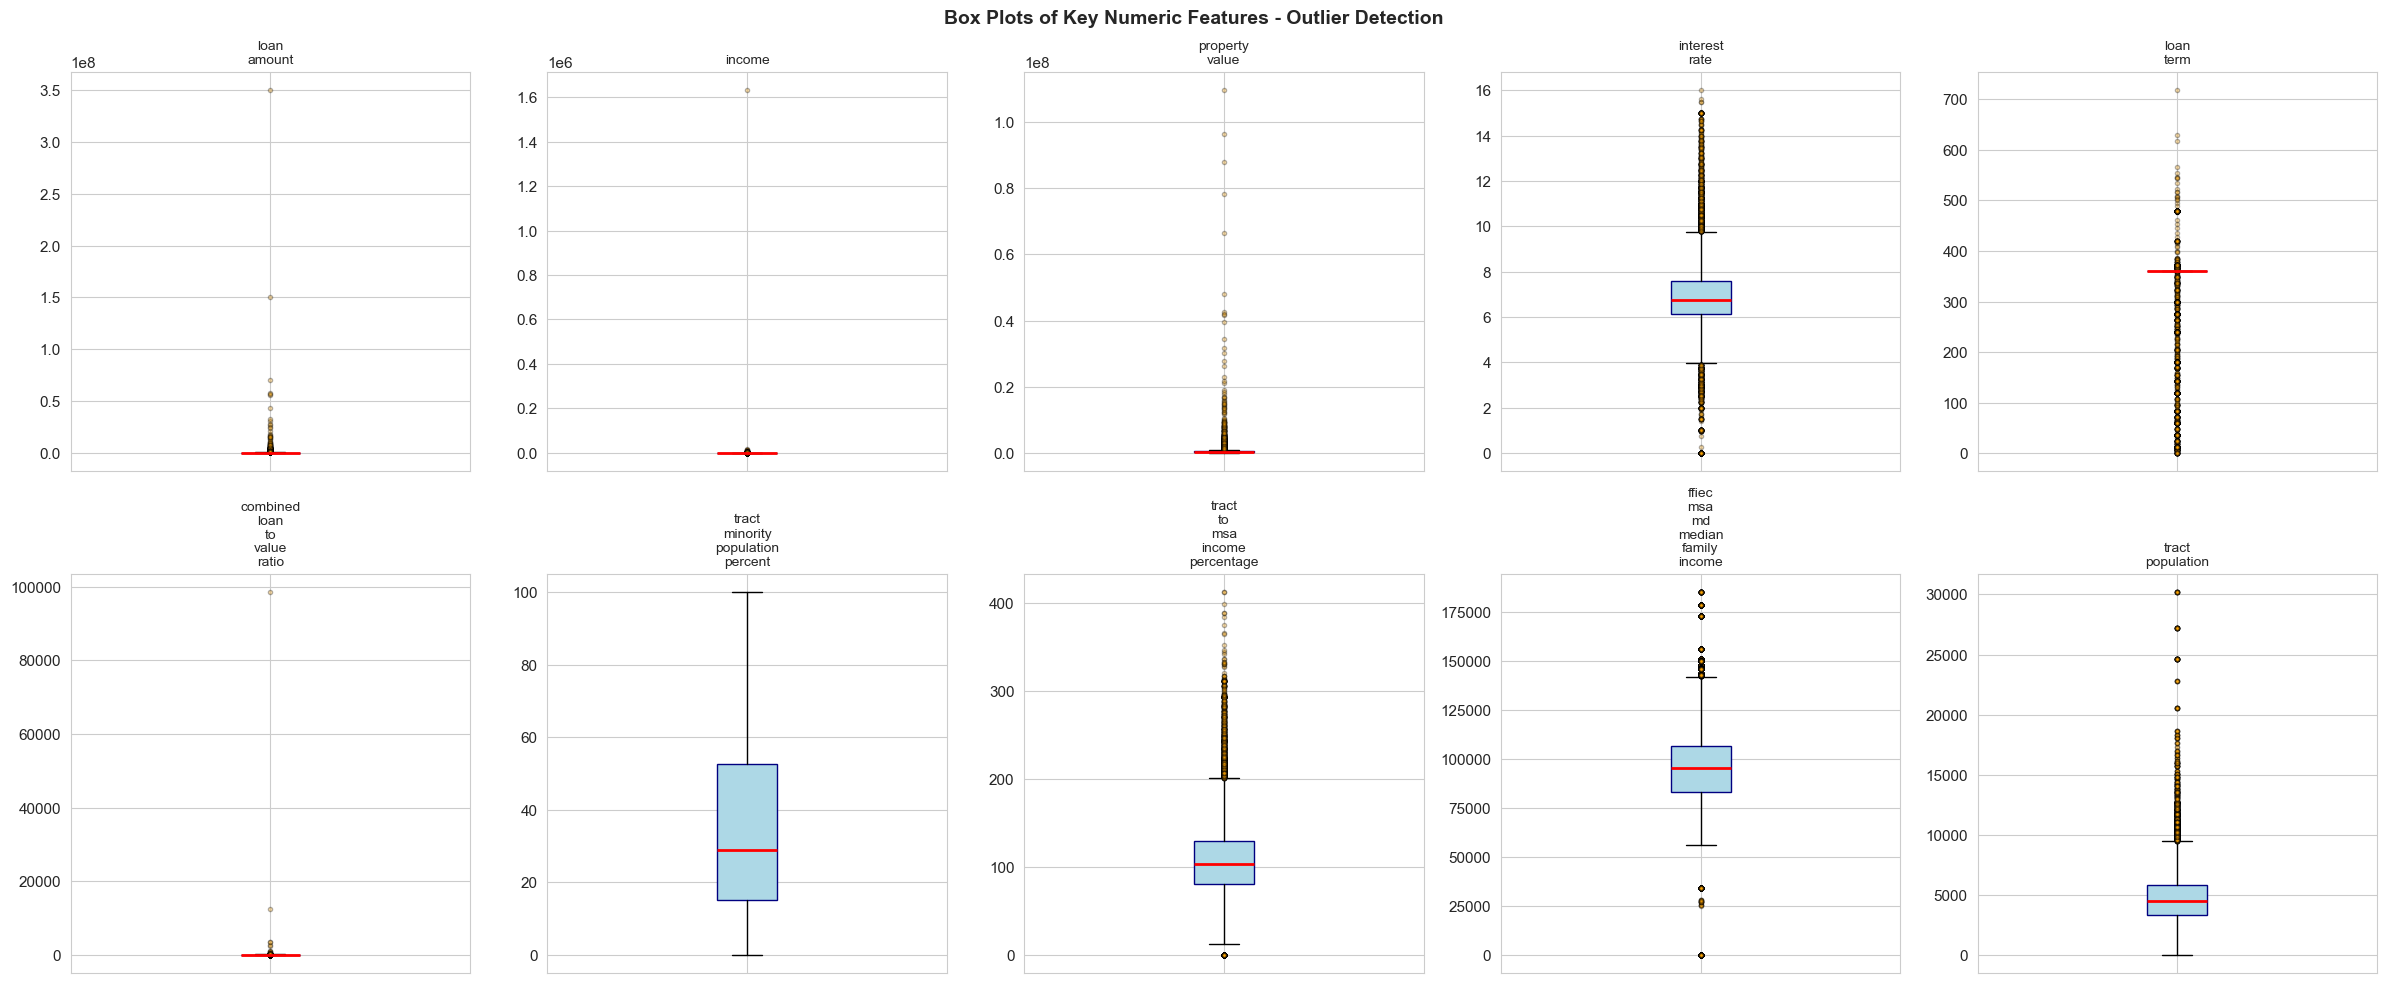

Saved: eda_boxplots.png


In [9]:
fig, axes = plt.subplots(2, 5, figsize=(24, 10))
axes = axes.flatten()

for i, col in enumerate(key_numeric):
    ax = axes[i]
    data = pd.to_numeric(sample_pdf[col], errors='coerce').dropna()
    
    if len(data) > 0:
        bp = ax.boxplot(data, vert=True, patch_artist=True,
                       boxprops=dict(facecolor='lightblue', color='navy'),
                       medianprops=dict(color='red', linewidth=2),
                       flierprops=dict(marker='o', markerfacecolor='orange', markersize=3, alpha=0.3))
    
    ax.set_title(col.replace("_", "\n"), fontsize=10)
    ax.set_xticklabels([])

plt.suptitle("Box Plots of Key Numeric Features - Outlier Detection", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../data/processed/eda_boxplots.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eda_boxplots.png")

## Section 3: Univariate Analysis - Categorical Features

In [10]:
# ============================================================
#  Cardinality Analysis for ALL Categorical Columns
# ============================================================


cat_cols_in_df = [c for c in CATEGORICAL_NOMINAL + CATEGORICAL_ORDINAL if c in df.columns]

print("=" * 80)
print(f"CARDINALITY ANALYSIS FOR {len(cat_cols_in_df)} CATEGORICAL COLUMNS")
print("=" * 80)
print(f"{'Column':<45} {'Unique Values':>15} {'Encoding Strategy':<25}")
print("-" * 90)

cardinality_info = []
for col in sorted(cat_cols_in_df):
    n_unique = df.select(col).distinct().count()
    
    if n_unique <= 2:
        strategy = "Binary (0/1)"
    elif n_unique <= 10:
        strategy = "One-Hot Encoding"
    elif n_unique <= 50:
        strategy = "Target / Ordinal Encoding"
    elif n_unique <= 500:
        strategy = "Frequency / Hash Encoding"
    else:
        strategy = "DROP or Group Key"
    
    cardinality_info.append({"column": col, "n_unique": n_unique, "strategy": strategy})
    print(f"  {col:<43} {n_unique:>15,}   {strategy:<25}")

print("\nNote: 'DROP or Group Key' means the column has too many unique values")
print("to encode directly - it's likely an identifier (lei, census_tract, etc.)")

CARDINALITY ANALYSIS FOR 75 CATEGORICAL COLUMNS
Column                                          Unique Values Encoding Strategy        
------------------------------------------------------------------------------------------
  action_taken                                              8   One-Hot Encoding         
  applicant_age                                             8   One-Hot Encoding         
  applicant_age_above_62                                    3   One-Hot Encoding         
  applicant_credit_score_type                              11   Target / Ordinal Encoding
  applicant_ethnicity_1                                     9   One-Hot Encoding         
  applicant_ethnicity_2                                     7   One-Hot Encoding         
  applicant_ethnicity_3                                     7   One-Hot Encoding         
  applicant_ethnicity_4                                     7   One-Hot Encoding         
  applicant_ethnicity_5                              

  census_tract                                         83,968   DROP or Group Key        
  co_applicant_age                                          9   One-Hot Encoding         
  co_applicant_age_above_62                                 3   One-Hot Encoding         
  co_applicant_credit_score_type                           12   Target / Ordinal Encoding
  co_applicant_ethnicity_1                                 11   Target / Ordinal Encoding
  co_applicant_ethnicity_2                                  7   One-Hot Encoding         
  co_applicant_ethnicity_3                                  7   One-Hot Encoding         
  co_applicant_ethnicity_4                                  7   One-Hot Encoding         
  co_applicant_ethnicity_5                                  5   One-Hot Encoding         
  co_applicant_ethnicity_observed                           4   One-Hot Encoding         
  co_applicant_race_1                                      20   Target / Ordinal Encoding
  co_appli

In [11]:
# ============================================================
# Value Counts for Key Categorical Features
# ============================================================

interesting_cats = [
    "loan_type", "loan_purpose", "lien_status", "occupancy_type",
    "construction_method", "preapproval", "derived_ethnicity", "derived_race",
    "derived_sex", "hoepa_status", "conforming_loan_limit",
    "reverse_mortgage", "open_end_line_of_credit", "business_or_commercial_purpose",
    "negative_amortization", "interest_only_payment", "balloon_payment",
    "applicant_credit_score_type", "aus_1", "submission_of_application",
    "debt_to_income_ratio", "applicant_age", "total_units"
]

for col in interesting_cats:
    if col not in df.columns:
        continue
    
    print(f"\n{'=' * 60}")
    print(f"  {col}")
    print(f"{'=' * 60}")
    
    vc = (df.groupBy(col)
          .count()
          .orderBy(F.desc("count"))
          .collect())
    
    for row in vc[:15]:  # Show top 15 values
        val = row[col]
        cnt = row["count"]
        pct = (cnt / total_rows) * 100
        bar = "#" * int(pct / 2)  # Simple text bar chart
        print(f"  {str(val):<35} {cnt:>12,} ({pct:>5.1f}%) {bar}")
    
    if len(vc) > 15:
        print(f"  ... and {len(vc) - 15} more values")


  loan_type
  1                                      8,876,548 ( 77.3%) ######################################
  2                                      1,706,586 ( 14.9%) #######
  3                                        826,014 (  7.2%) ###
  4                                         74,741 (  0.7%) 

  loan_purpose
  1                                      6,541,315 ( 57.0%) ############################
  32                                     1,539,673 ( 13.4%) ######
  4                                      1,273,880 ( 11.1%) #####
  2                                      1,233,349 ( 10.7%) #####
  31                                       840,169 (  7.3%) ###
  5                                         55,503 (  0.5%) 

  lien_status
  1                                      8,875,475 ( 77.3%) ######################################
  2                                      2,608,414 ( 22.7%) ###########

  occupancy_type
  1                                     10,413,871 ( 90.7%) ##

In [12]:
# ============================================================
# Near-Zero Variance Detection
# ============================================================

print("=" * 80)
print("NEAR-ZERO VARIANCE DETECTION (dominant value > 95%)")
print("=" * 80)

nzv_cols = []
for col in cat_cols_in_df:
    if col in ["lei", "census_tract", "county_code"]:  # Skip identifiers
        continue
    
    # Get the most frequent value's count
    top_val = df.groupBy(col).count().orderBy(F.desc("count")).first()
    if top_val is not None:
        dominance = top_val["count"] / total_rows * 100
        if dominance > 95:
            nzv_cols.append({"column": col, "dominant_value": str(top_val[col]), "dominance_pct": dominance})
            print(f"  {col:<45} dominant='{top_val[col]}' at {dominance:.1f}%")

if not nzv_cols:
    print("  No near-zero variance columns found.")
else:
    print(f"\nFound {len(nzv_cols)} near-zero variance columns.")
    print("RECOMMENDATION: Consider dropping these or using them only as binary flags.")

NEAR-ZERO VARIANCE DETECTION (dominant value > 95%)
  conforming_loan_limit                         dominant='C' at 96.5%
  reverse_mortgage                              dominant='2' at 97.2%
  negative_amortization                         dominant='2' at 97.5%
  other_nonamortizing_features                  dominant='2' at 97.2%
  applicant_ethnicity_3                         dominant='None' at 99.9%
  applicant_ethnicity_4                         dominant='None' at 100.0%
  applicant_ethnicity_5                         dominant='None' at 100.0%
  co_applicant_ethnicity_2                      dominant='None' at 97.8%
  co_applicant_ethnicity_3                      dominant='None' at 100.0%
  co_applicant_ethnicity_4                      dominant='None' at 100.0%
  co_applicant_ethnicity_5                      dominant='None' at 100.0%
  applicant_race_2                              dominant='None' at 95.2%
  applicant_race_3                              dominant='None' at 99.6%
  appl

## Section 4: Bivariate Analysis - Each Feature vs. Denial

In [13]:
# ============================================================
# Filter to Target Classes & Create Label
# ============================================================

df_target = df.filter(F.col("action_taken").isin(1, 3))

df_target = df_target.withColumn(
    "label",
    F.when(F.col("action_taken") == 3, 1).otherwise(0)
)

target_total = df_target.count()
denied_count = df_target.filter(F.col("label") == 1).count()
originated_count = target_total - denied_count

print(f"Target population: {target_total:,} records")
print(f"  Originated (label=0): {originated_count:,} ({originated_count/target_total*100:.1f}%)")
print(f"  Denied     (label=1): {denied_count:,} ({denied_count/target_total*100:.1f}%)")

df_target.cache()
df_target.count()
print("Cached target DataFrame.")

Target population: 7,686,484 records
  Originated (label=0): 5,691,726 (74.0%)
  Denied     (label=1): 1,994,758 (26.0%)


Cached target DataFrame.


In [14]:
# ============================================================
# Numeric Features vs. Target - Distribution Comparison
# ============================================================

# WHY compare distributions?
# If the distribution of loan_amount is DIFFERENT for denied vs. originated,
# then loan_amount carries predictive signal. If distributions are identical,
# the feature is useless for predicting denial.

# Select numeric features that are NOT leakage and available
non_leak_numeric = [c for c in NUMERIC_CONTINUOUS if c not in LEAKAGE_COLS and c in df_target.columns]

print("=" * 100)
print("NUMERIC FEATURES: DENIED vs. ORIGINATED")
print("=" * 100)
print(f"{'Column':<40} {'Originated Mean':>16} {'Denied Mean':>14} {'Diff %':>8} {'T-stat':>10} {'P-value':>10}")
print("-" * 100)

bivariate_numeric = []

for col in non_leak_numeric:
    # Compute means by class
    stats_by_class = (df_target
        .groupBy("label")
        .agg(
            F.mean(col).alias("mean"),
            F.stddev(col).alias("std"),
            F.count(col).alias("cnt")
        )
        .collect()
    )
    
    orig_stats = next((r for r in stats_by_class if r["label"] == 0), None)
    deny_stats = next((r for r in stats_by_class if r["label"] == 1), None)
    
    if orig_stats and deny_stats and orig_stats["mean"] is not None and deny_stats["mean"] is not None:
        orig_mean = orig_stats["mean"]
        deny_mean = deny_stats["mean"]
        diff_pct = ((deny_mean - orig_mean) / orig_mean * 100) if orig_mean != 0 else 0
        
        # Welch's t-test (assumes unequal variances)
        t_stat = None
        p_val = None
        if orig_stats["std"] and deny_stats["std"] and orig_stats["std"] > 0:
            t_stat = (deny_mean - orig_mean) / np.sqrt(
                (deny_stats["std"]**2 / deny_stats["cnt"]) + 
                (orig_stats["std"]**2 / orig_stats["cnt"])
            )
            # For large N, t-distribution ~ normal, so use norm.sf for p-value
            p_val = 2 * stats.norm.sf(abs(t_stat))
        
        bivariate_numeric.append({
            "column": col, "orig_mean": orig_mean, "deny_mean": deny_mean,
            "diff_pct": diff_pct, "t_stat": t_stat, "p_value": p_val
        })
        
        sig = "***" if (p_val is not None and p_val < 0.001) else "**" if (p_val is not None and p_val < 0.01) else "*" if (p_val is not None and p_val < 0.05) else "ns"
        t_s = f"{t_stat:>10.2f}" if t_stat is not None else f"{'N/A':>10}"
        p_s = f"{p_val:>10.2e}" if p_val is not None else f"{'N/A':>10}"
        
        print(f"  {col:<38} {orig_mean:>16.2f} {deny_mean:>14.2f} {diff_pct:>7.1f}% {t_s} {p_s} {sig}")

print("\n*** p < 0.001  |  ** p < 0.01  |  * p < 0.05  |  ns = not significant")
print("\nInterpretation: Columns with *** have HIGHLY significant differences between")
print("denied and originated loans - they carry strong predictive signal.")

NUMERIC FEATURES: DENIED vs. ORIGINATED
Column                                    Originated Mean    Denied Mean   Diff %     T-stat    P-value
----------------------------------------------------------------------------------------------------
  loan_amount                                   312122.88      316947.69     1.5%       0.04   9.67e-01 ns
  combined_loan_to_value_ratio                     113.03        5853.20  5078.5%       1.99   4.61e-02 *
  loan_term                                        320.29         310.97    -2.9%    -131.13   0.00e+00 ***
  intro_rate_period                                 27.03           9.15   -66.2%    -549.75   0.00e+00 ***
  property_value                                548126.50      494079.59    -9.9%     -12.31   8.28e-35 ***


  multifamily_affordable_units                       8.33           3.62   -56.5%    -288.04   0.00e+00 ***
  income                                           175.31         207.89    18.6%       0.46   6.42e-01 ns
  tract_population                                4822.12        4583.82    -4.9%    -130.32   0.00e+00 ***
  tract_minority_population_percent                 35.01          38.87    11.0%     172.30   0.00e+00 ***
  ffiec_msa_md_median_family_income              98329.27       94750.34    -3.6%    -177.82   0.00e+00 ***
  tract_to_msa_income_percentage                   110.77         101.43    -8.4%    -262.43   0.00e+00 ***
  tract_owner_occupied_units                      1243.32        1152.23    -7.3%    -186.87   0.00e+00 ***
  tract_one_to_four_family_homes                  1670.66        1586.22    -5.1%    -143.63   0.00e+00 ***
  tract_median_age_of_housing_units                 35.97          35.29    -1.9%     -44.21   0.00e+00 ***

*** p < 0.001  |  ** p < 0.0

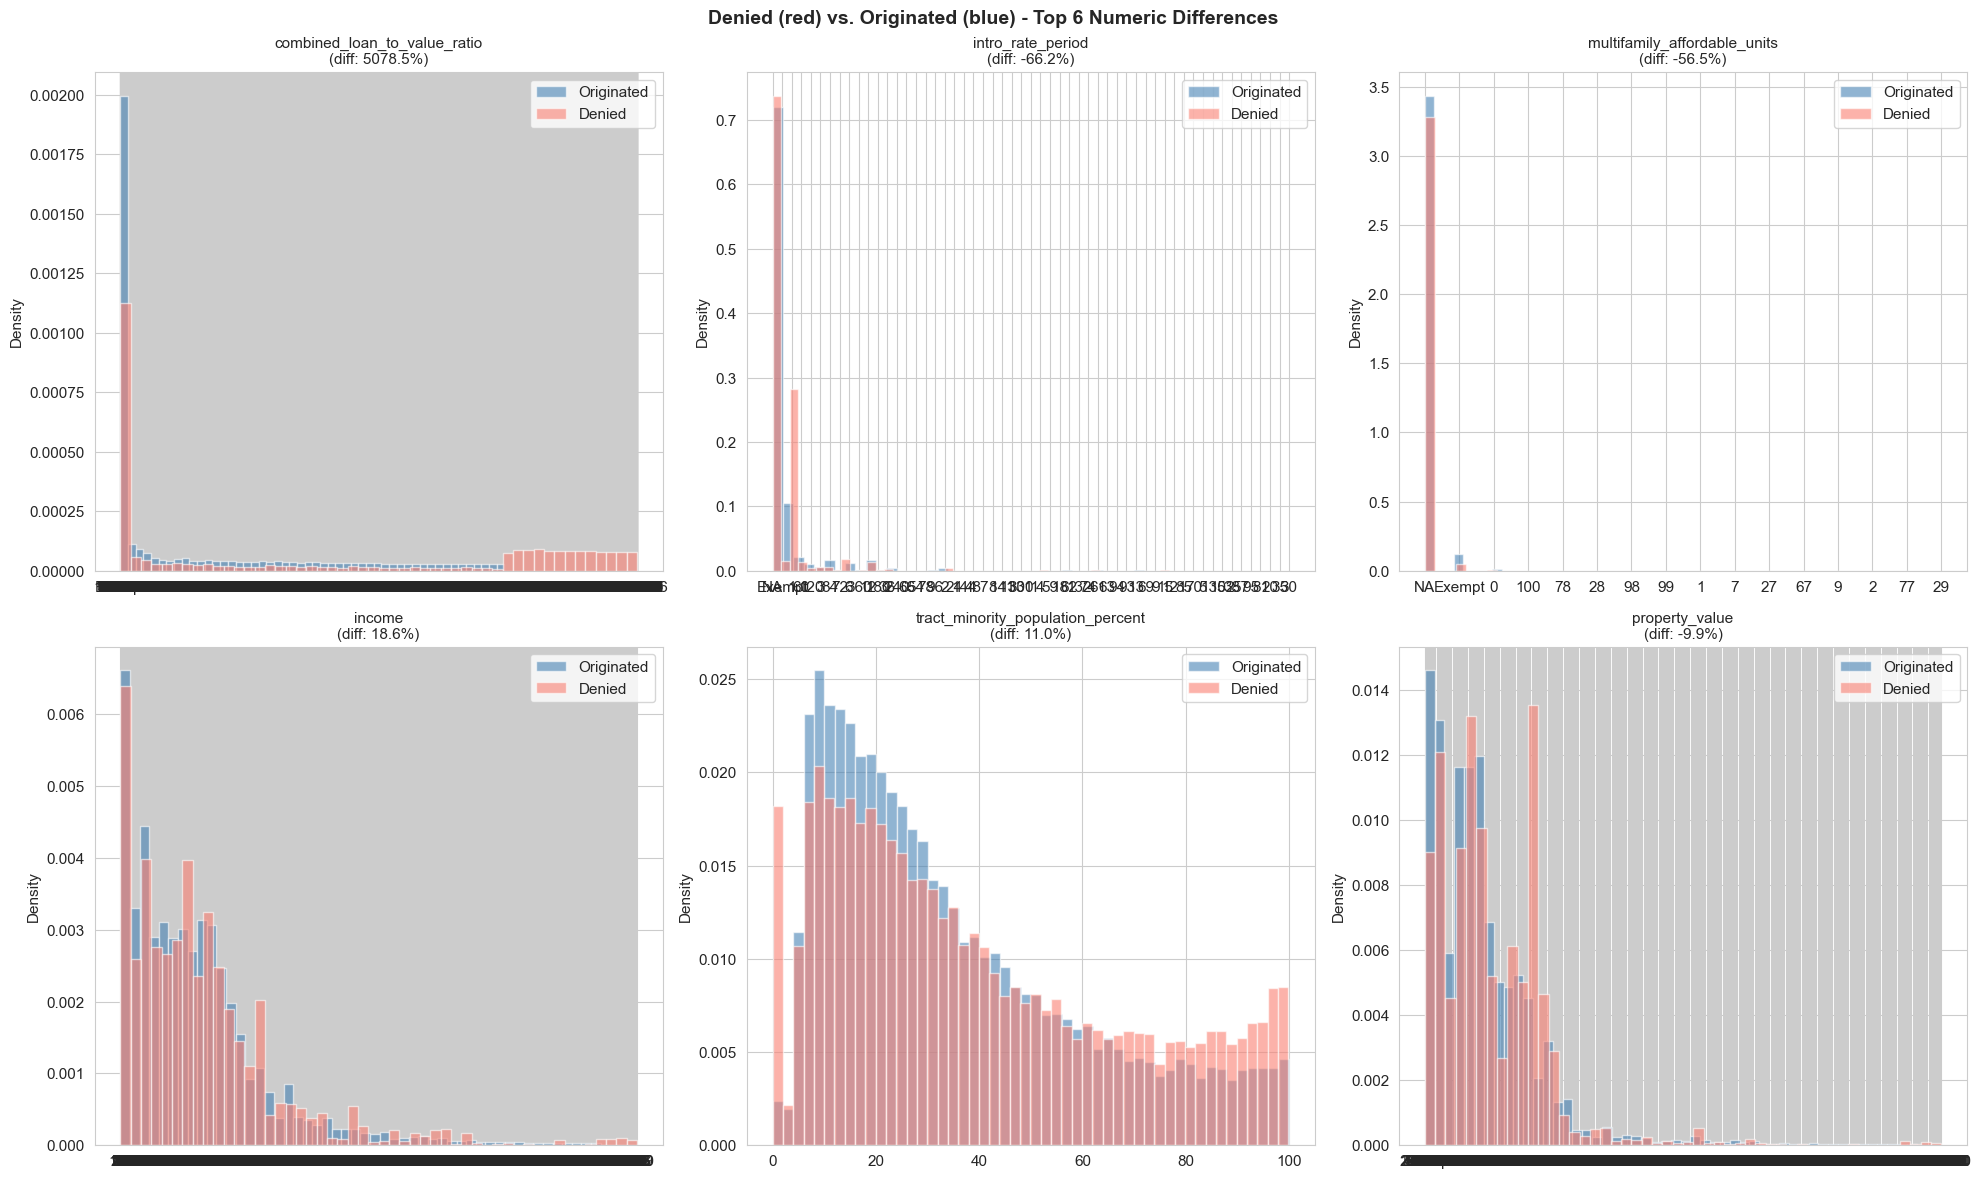

Saved: eda_numeric_bivariate.png


In [16]:
# ============================================================
#  Visualize Top Numeric Differences - Denied vs Originated
# ============================================================

# Sort by absolute diff percentage and take top 6
top_diff = sorted(bivariate_numeric, key=lambda x: abs(x.get("diff_pct", 0)), reverse=True)[:6]
top_diff_cols = [d["column"] for d in top_diff]

# Sample for plotting
sample_target = (df_target
    .select(top_diff_cols + ["label"])
    .sample(fraction=50000/target_total, seed=42)
    .toPandas()
)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(top_diff_cols):
    ax = axes[i]
    orig = sample_target[sample_target["label"] == 0][col].dropna()
    deny = sample_target[sample_target["label"] == 1][col].dropna()
    
    ax.hist(orig, bins=50, alpha=0.6, label="Originated", color="steelblue", density=True)
    ax.hist(deny, bins=50, alpha=0.6, label="Denied", color="salmon", density=True)
    
    stat = next((d for d in top_diff if d["column"] == col), {})
    ax.set_title(f"{col}\n(diff: {stat.get('diff_pct', 0):.1f}%)", fontsize=11)
    ax.legend()
    ax.set_ylabel("Density")

plt.suptitle("Denied (red) vs. Originated (blue) - Top 6 Numeric Differences", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../data/processed/eda_numeric_bivariate.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eda_numeric_bivariate.png")

In [17]:
# ============================================================
# Categorical Features vs. Target - Denial Rate by Category
# ============================================================

non_leak_categorical = [c for c in CATEGORICAL_NOMINAL + CATEGORICAL_ORDINAL 
                         if c not in LEAKAGE_COLS and c in df_target.columns
                         and c not in ["lei", "census_tract", "county_code", "activity_year", "derived_msa_md"]]

print("=" * 90)
print("DENIAL RATES BY CATEGORICAL FEATURE")
print("=" * 90)

denial_rate_results = {}

for col in non_leak_categorical:
    # Compute denial rate per category
    rates = (df_target
        .groupBy(col)
        .agg(
            F.count("*").alias("total"),
            F.sum("label").alias("denied"),
        )
        .withColumn("denial_rate", F.col("denied") / F.col("total"))
        .orderBy(F.desc("total"))
        .collect()
    )
    
    if len(rates) > 1:
        denial_rate_results[col] = rates
        
        # Print top categories
        print(f"\n--- {col} (top categories) ---")
        for row in rates[:10]:
            val = str(row[col])[:30]
            total = row["total"]
            denied = row["denied"]
            rate = row["denial_rate"] * 100
            bar = "#" * int(rate)
            print(f"    {val:<32} {total:>10,} records | denial: {rate:>5.1f}% {bar}")

DENIAL RATES BY CATEGORICAL FEATURE

--- state_code (top categories) ---
    FL                                  671,671 records | denial:  30.9% ##############################
    TX                                  652,837 records | denial:  28.8% ############################
    CA                                  586,451 records | denial:  26.8% ##########################
    NC                                  326,614 records | denial:  25.3% #########################
    PA                                  313,383 records | denial:  25.5% #########################
    OH                                  300,885 records | denial:  24.6% ########################
    GA                                  294,097 records | denial:  29.0% #############################
    NY                                  278,146 records | denial:  27.0% ##########################
    MI                                  248,506 records | denial:  25.3% #########################
    IL                 

In [18]:
# ============================================================
# Chi-Square Tests for Categorical Features
# ============================================================

print("=" * 90)
print("CHI-SQUARE TEST OF INDEPENDENCE: Feature vs. Denial")
print("=" * 90)
print(f"{'Column':<40} {'Chi2':>12} {'P-value':>12} {'Cramers V':>10} {'Effect':>12}")
print("-" * 90)

chi2_results = []

for col in non_leak_categorical:
    rates = denial_rate_results.get(col, [])
    if len(rates) < 2:
        continue
    
    # observed[i][j] = count of category i with label j
    observed = []
    for row in rates:
        denied = int(row["denied"]) if row["denied"] else 0
        originated = int(row["total"]) - denied
        observed.append([originated, denied])
    
    observed = np.array(observed)
    
    # Remove rows with zero total (causes division errors)
    observed = observed[observed.sum(axis=1) > 0]
    
    if observed.shape[0] < 2:
        continue
    
    try:
        chi2, p_value, dof, expected = stats.chi2_contingency(observed)
        
        n = observed.sum()
        min_dim = min(observed.shape[0], observed.shape[1]) - 1
        cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0
        
        effect = "STRONG" if cramers_v > 0.5 else "MODERATE" if cramers_v > 0.3 else "WEAK" if cramers_v > 0.1 else "Negligible"
        
        chi2_results.append({
            "column": col, "chi2": chi2, "p_value": p_value,
            "cramers_v": cramers_v, "effect": effect, "dof": dof
        })
        
        sig = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
        print(f"  {col:<38} {chi2:>12.1f} {p_value:>12.2e} {cramers_v:>10.4f} {effect:>12} {sig}")
    except:
        print(f"  {col:<38} {'SKIPPED':>12}")

chi2_results.sort(key=lambda x: x.get("cramers_v", 0), reverse=True)
print("\nTop 10 features by Cramer's V (practical importance):")
for i, r in enumerate(chi2_results[:10], 1):
    print(f"  {i}. {r['column']:<40} V={r['cramers_v']:.4f} ({r['effect']})")

CHI-SQUARE TEST OF INDEPENDENCE: Feature vs. Denial
Column                                           Chi2      P-value  Cramers V       Effect
------------------------------------------------------------------------------------------
  state_code                                 109810.8     0.00e+00     0.1195         WEAK ***
  derived_loan_product_type                  235319.3     0.00e+00     0.1750         WEAK ***
  derived_dwelling_category                  315609.4     0.00e+00     0.2026         WEAK ***
  conforming_loan_limit                       10848.3     0.00e+00     0.0376   Negligible ***
  derived_ethnicity                           39740.5     0.00e+00     0.0719   Negligible ***
  derived_race                               106075.7     0.00e+00     0.1175         WEAK ***
  derived_sex                                 98784.9     0.00e+00     0.1134         WEAK ***
  loan_type                                   33227.9     0.00e+00     0.0657   Negligible ***
  loan

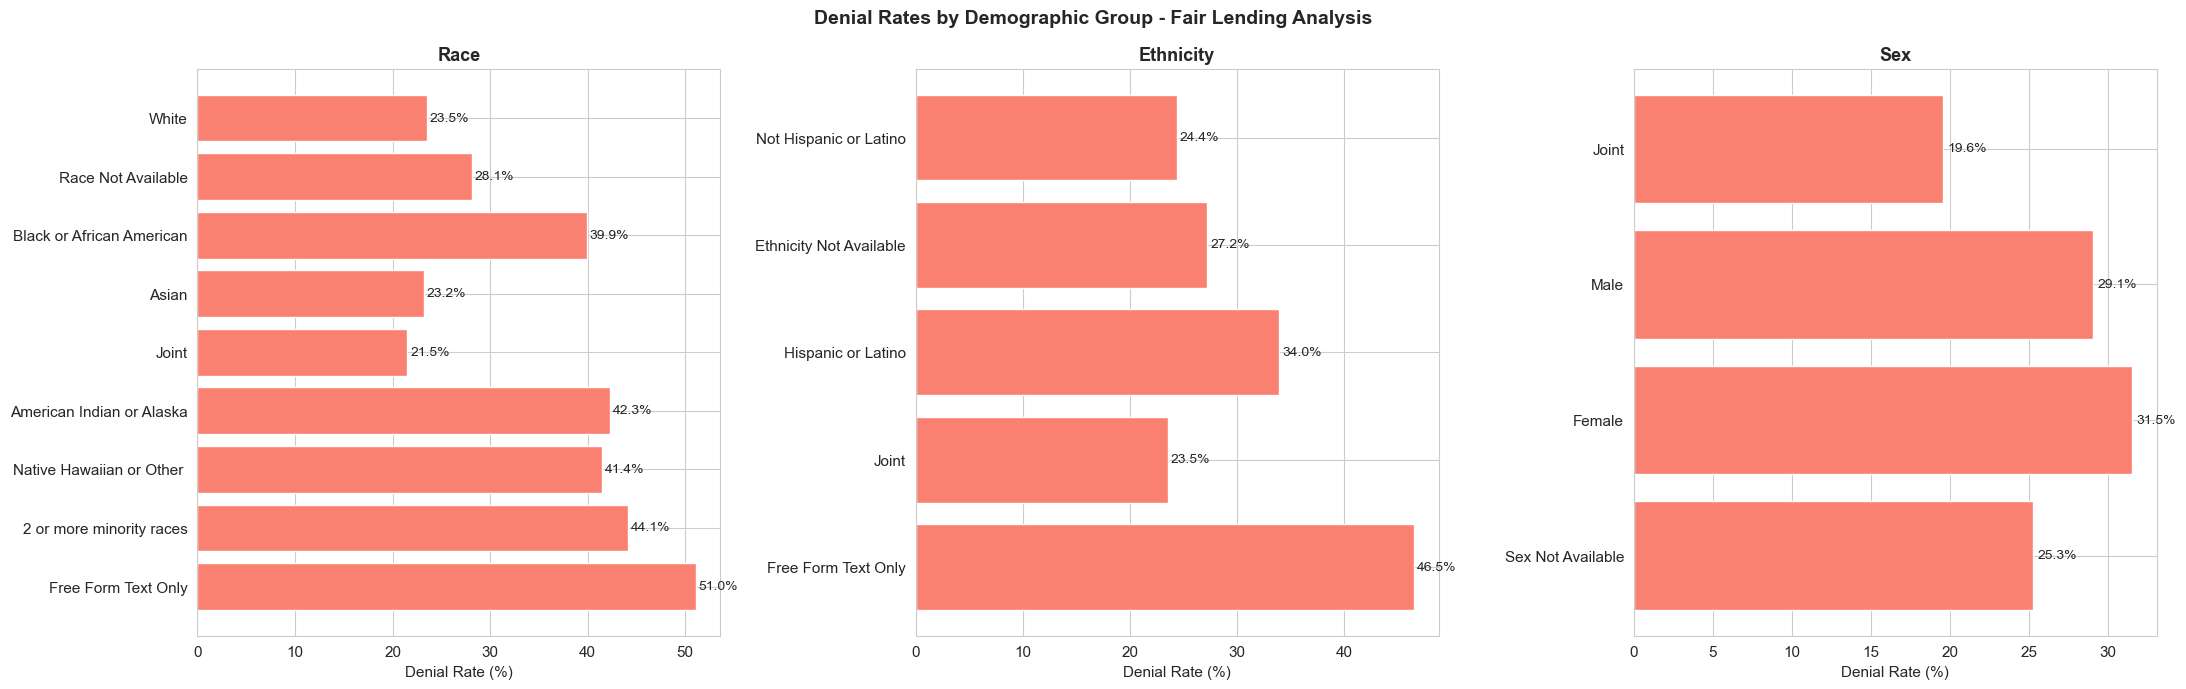

Saved: eda_fair_lending.png


In [19]:
# ============================================================
#  Denial Rate Visualization - Demographics (Fair Lending)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

demographic_cols = ["derived_race", "derived_ethnicity", "derived_sex"]

for i, col in enumerate(demographic_cols):
    if col not in denial_rate_results:
        continue
    
    rates = denial_rate_results[col]
    categories = [str(r[col])[:25] for r in rates if r["total"] > 1000][:10]
    denial_rates = [r["denial_rate"] * 100 for r in rates if r["total"] > 1000][:10]
    
    ax = axes[i]
    bars = ax.barh(categories, denial_rates, color=['salmon' if d > 15 else 'steelblue' for d in denial_rates])
    ax.set_xlabel("Denial Rate (%)")
    ax.set_title(col.replace("derived_", "").title(), fontsize=13, fontweight='bold')
    
    # Add value labels
    for bar, rate in zip(bars, denial_rates):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{rate:.1f}%', va='center', fontsize=10)
    
    ax.invert_yaxis()

plt.suptitle("Denial Rates by Demographic Group - Fair Lending Analysis", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../data/processed/eda_fair_lending.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eda_fair_lending.png")

## Section 5: Correlation Analysis & Multicollinearity Detection

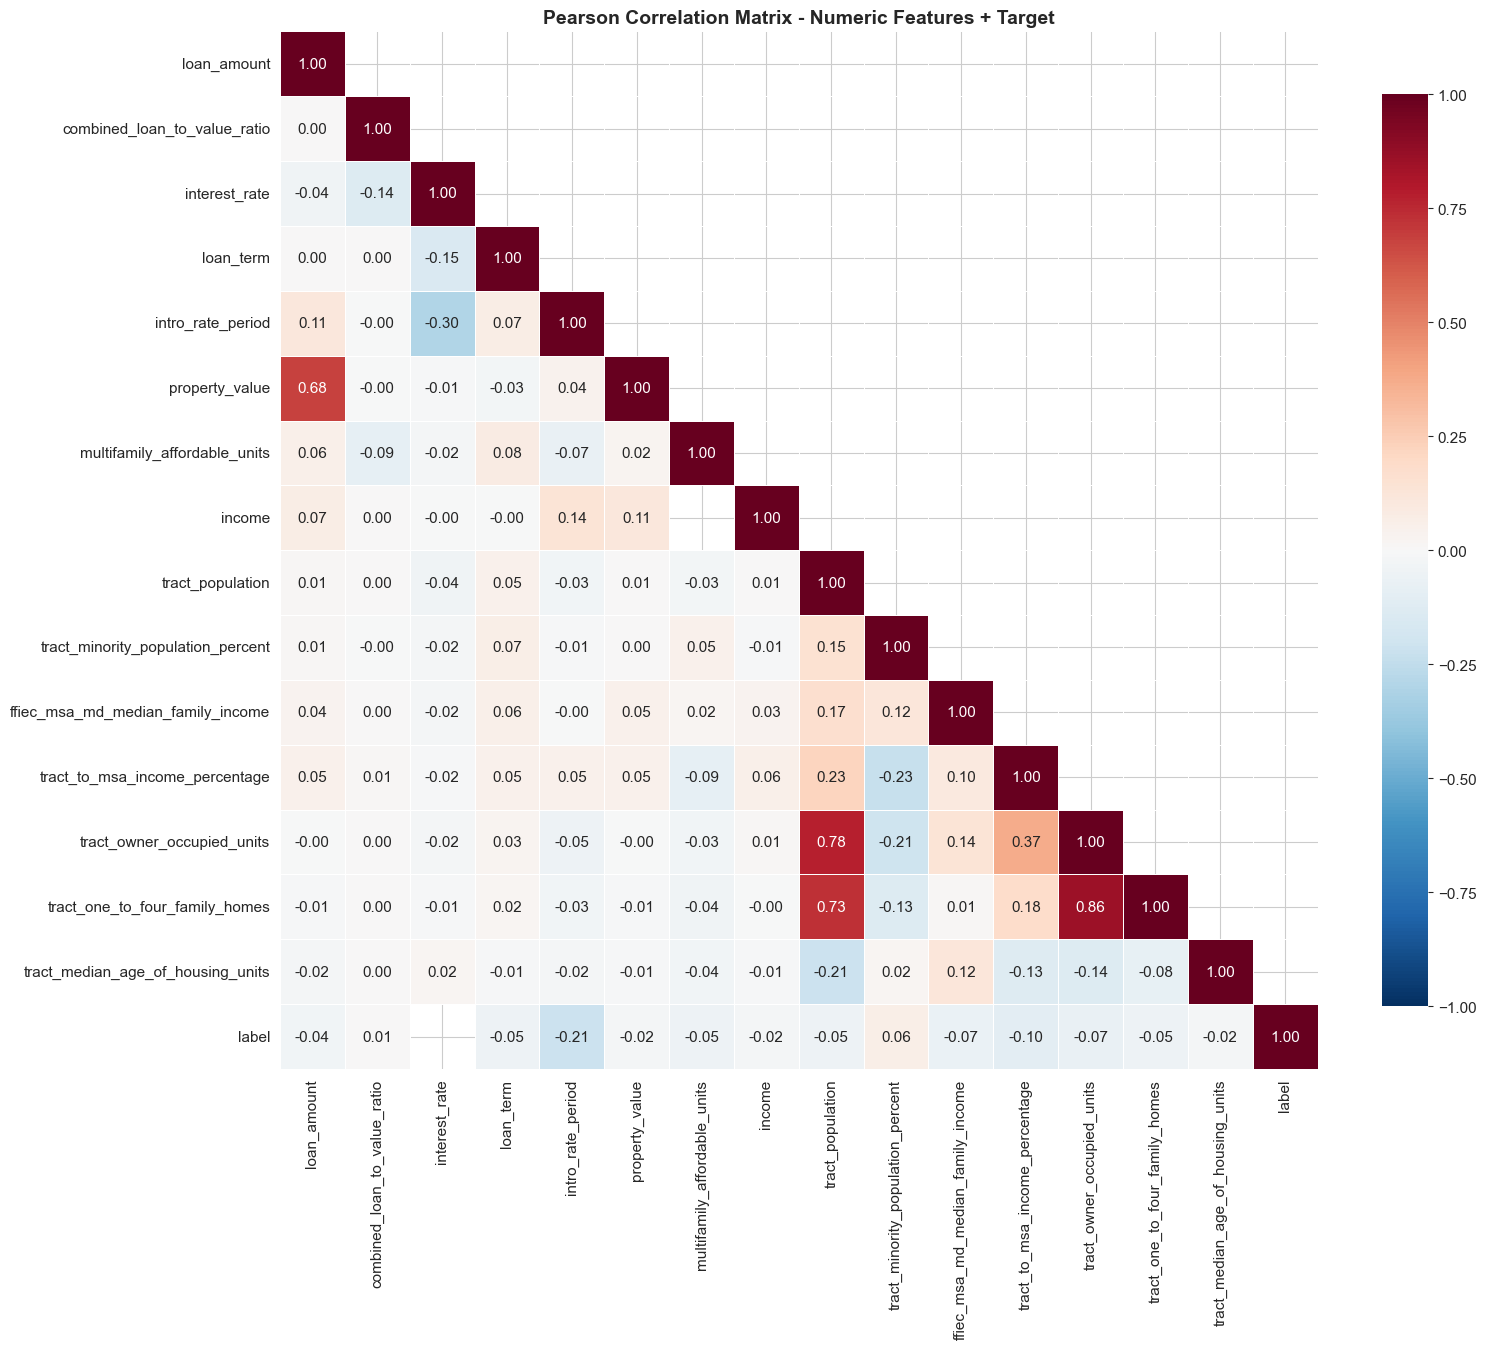

Saved: eda_correlation_matrix.png


In [21]:
# ============================================================
# Correlation Matrix for Numeric Features
# ============================================================

corr_cols = [c for c in non_leak_numeric if c in df_target.columns]

sample_for_corr = (df_target
    .select(corr_cols + ["label"])
    .sample(fraction=100000/target_total, seed=42)
    .toPandas()
)

# Convert all columns to numeric (coerce "Exempt"/"NA"/"1111-1" strings to NaN)
for col in sample_for_corr.columns:
    sample_for_corr[col] = pd.to_numeric(sample_for_corr[col], errors='coerce')

# Compute Pearson correlation matrix
corr_matrix = sample_for_corr.corr(method='pearson')

# Plot heatmap
plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # Show only lower triangle
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Pearson Correlation Matrix - Numeric Features + Target", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../data/processed/eda_correlation_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eda_correlation_matrix.png")

In [22]:
# ============================================================
# Identify Multicollinear Pairs & Target Correlations
# ============================================================

# MULTICOLLINEARITY: Find feature pairs with |r| > 0.8
print("=" * 70)
print("MULTICOLLINEAR PAIRS (|r| > 0.8)")
print("=" * 70)

multicoll_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        col_i = corr_matrix.columns[i]
        col_j = corr_matrix.columns[j]
        if col_i == "label" or col_j == "label":
            continue
        r = corr_matrix.iloc[i, j]
        if not np.isnan(r) and abs(r) > 0.8:
            multicoll_pairs.append((col_i, col_j, r))
            print(f"  {col_i:<35} <-> {col_j:<35} r={r:.3f}")

if not multicoll_pairs:
    print("  No multicollinear pairs found (good!)")
else:
    print(f"\n  Found {len(multicoll_pairs)} pair(s). Consider dropping one from each pair.")

# TARGET CORRELATIONS: Rank features by |correlation with label|
print("\n" + "=" * 70)
print("FEATURE CORRELATIONS WITH TARGET (label)")
print("=" * 70)

if "label" in corr_matrix.columns:
    target_corr = corr_matrix["label"].drop("label").abs().sort_values(ascending=False)
    for col, r in target_corr.items():
        if np.isnan(r):
            print(f"  {col:<40} |r|=  NaN   (all values missing/non-numeric)")
            continue
        strength = "STRONG" if r > 0.3 else "MODERATE" if r > 0.1 else "WEAK" if r > 0.05 else "Negligible"
        bar = "#" * int(r * 50)
        print(f"  {col:<40} |r|={r:.4f}  {strength:<12} {bar}")

print("Non-linear relationships (e.g., debt_to_income_ratio) may still be highly predictive.")

MULTICOLLINEAR PAIRS (|r| > 0.8)
  tract_owner_occupied_units          <-> tract_one_to_four_family_homes      r=0.858

  Found 1 pair(s). Consider dropping one from each pair.

FEATURE CORRELATIONS WITH TARGET (label)
  intro_rate_period                        |r|=0.2115  MODERATE     ##########
  tract_to_msa_income_percentage           |r|=0.1027  MODERATE     #####
  tract_owner_occupied_units               |r|=0.0720  WEAK         ###
  ffiec_msa_md_median_family_income        |r|=0.0679  WEAK         ###
  tract_minority_population_percent        |r|=0.0639  WEAK         ###
  multifamily_affordable_units             |r|=0.0531  WEAK         ##
  tract_one_to_four_family_homes           |r|=0.0528  WEAK         ##
  tract_population                         |r|=0.0508  WEAK         ##
  loan_term                                |r|=0.0496  Negligible   ##
  loan_amount                              |r|=0.0383  Negligible   #
  income                                   |r|=0.0184  Neg

## Section 6: Missing Value Pattern Analysis

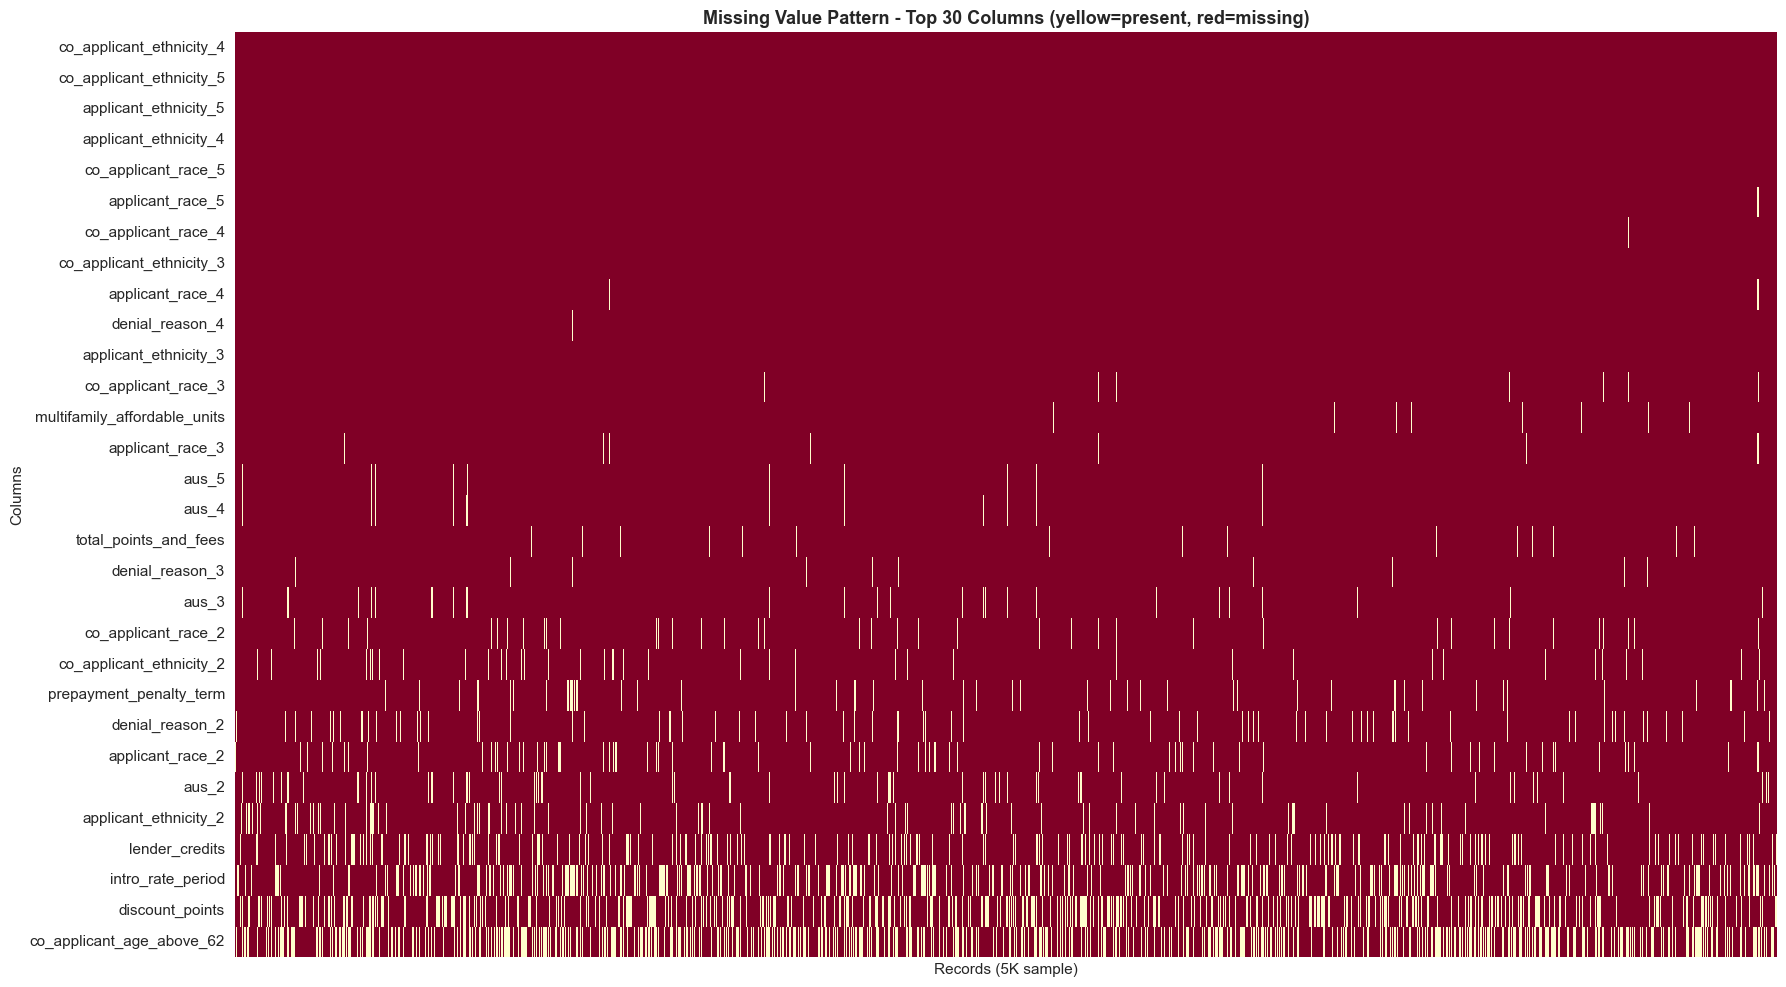

Saved: eda_missing_heatmap.png

Highly correlated missing patterns (missing together):
  aus_5                               + aus_4                               r=0.913
  applicant_race_5                    + applicant_race_4                    r=0.756


In [23]:
# ============================================================
# Missing Value Heatmap - Top 30 Columns
# ============================================================

# Get columns with most missingness
profile_df = pd.read_csv("../data/processed/initial_profile.csv")
top_missing = profile_df.nlargest(30, "total_missing_pct")["column"].tolist()

if len(top_missing) > 0:
    # Sample for visualization
    missing_sample = (df
        .select(top_missing)
        .sample(fraction=5000/total_rows, seed=42)
        .toPandas()
    )
    
    # Create binary missing indicator matrix
    missing_matrix = missing_sample.isnull() | missing_sample.isin(["Exempt", "NA", "", "1111"])
    
    plt.figure(figsize=(18, 10))
    sns.heatmap(missing_matrix.T, cbar=False, cmap="YlOrRd",
                yticklabels=True, xticklabels=False)
    plt.title("Missing Value Pattern - Top 30 Columns (yellow=present, red=missing)", fontsize=13, fontweight='bold')
    plt.xlabel("Records (5K sample)")
    plt.ylabel("Columns")
    plt.tight_layout()
    plt.savefig("../data/processed/eda_missing_heatmap.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: eda_missing_heatmap.png")
    
    # Correlation between missing indicator
    missing_corr = missing_matrix.corr()
    high_miss_corr = []
    for i in range(len(missing_corr.columns)):
        for j in range(i+1, len(missing_corr.columns)):
            r = missing_corr.iloc[i, j]
            if abs(r) > 0.7 and not np.isnan(r):
                high_miss_corr.append((missing_corr.columns[i], missing_corr.columns[j], r))
    
    if high_miss_corr:
        print("\nHighly correlated missing patterns (missing together):")
        for a, b, r in sorted(high_miss_corr, key=lambda x: -abs(x[2]))[:10]:
            print(f"  {a:<35} + {b:<35} r={r:.3f}")
else:
    print("No columns with significant missing values found.")

In [24]:
# ============================================================
# Missingness vs. Target - Is Missing Data Informative?
# ============================================================

print("=" * 80)
print("MISSINGNESS vs. DENIAL RATE")
print("=" * 80)
print(f"{'Column':<40} {'Denial when Present':>20} {'Denial when Missing':>20} {'Gap':>8}")
print("-" * 90)

informative_missing = []
for col in df_target.columns:
    if col in ["action_taken", "label", "_corrupt_record"]:
        continue
    
    # Denial rate when column is present vs. missing
    rates = (df_target
        .withColumn("is_missing", 
                    F.when(F.col(col).isNull() | F.col(col).isin("Exempt", "NA", "", "1111"), 1).otherwise(0))
        .groupBy("is_missing")
        .agg(
            F.count("*").alias("total"),
            F.avg("label").alias("denial_rate")
        )
        .collect()
    )
    
    present_rate = next((r["denial_rate"] for r in rates if r["is_missing"] == 0), None)
    missing_rate = next((r["denial_rate"] for r in rates if r["is_missing"] == 1), None)
    
    if present_rate is not None and missing_rate is not None:
        gap = abs(missing_rate - present_rate) * 100
        if gap > 2:  # Only show meaningful gaps
            informative_missing.append({"column": col, "present_rate": present_rate*100,
                                        "missing_rate": missing_rate*100, "gap": gap})
            print(f"  {col:<38} {present_rate*100:>19.1f}% {missing_rate*100:>19.1f}% {gap:>7.1f}%")

informative_missing.sort(key=lambda x: x["gap"], reverse=True)

print(f"\nFound {len(informative_missing)} columns where missingness is informative.")

MISSINGNESS vs. DENIAL RATE
Column                                    Denial when Present  Denial when Missing      Gap
------------------------------------------------------------------------------------------
  county_code                                           25.6%                66.0%    40.4%
  census_tract                                          25.3%                76.1%    50.8%
  conforming_loan_limit                                 26.0%                 9.9%    16.2%
  reverse_mortgage                                      26.4%                13.0%    13.4%
  open_end_line_of_credit                               26.4%                13.0%    13.4%
  business_or_commercial_purpose                        26.4%                13.0%    13.4%
  combined_loan_to_value_ratio                          23.5%                48.4%    24.9%
  interest_rate                                          0.0%                90.2%    90.2%
  rate_spread                                        

## Section 7: Data Leakage Audit

In [25]:
# ============================================================
# Data Leakage Verification
# ============================================================

print("=" * 80)
print("DATA LEAKAGE AUDIT - Empirical Verification")
print("=" * 80)

for col in LEAKAGE_COLS:
    if col not in df_target.columns:
        print(f"  {col:<40} NOT IN DATAFRAME - skipped")
        continue

    fill_rates = (df_target
        .withColumn("is_filled",
                    F.when(
                        F.col(col).isNotNull() & 
                        ~F.col(col).isin("NA", "Exempt", "", "1111", "10"),
                        1
                    ).otherwise(0))
        .groupBy("label")
        .agg(F.avg("is_filled").alias("fill_rate"))
        .collect()
    )
    
    orig_fill = next((r["fill_rate"] for r in fill_rates if r["label"] == 0), 0)
    deny_fill = next((r["fill_rate"] for r in fill_rates if r["label"] == 1), 0)
    
    leak_flag = "CONFIRMED LEAKAGE" if abs(orig_fill - deny_fill) > 0.3 else "MILD LEAKAGE" if abs(orig_fill - deny_fill) > 0.1 else "CHECK MANUALLY"
    
    print(f"  {col:<40} Originated fill: {orig_fill*100:>5.1f}%  |  Denied fill: {deny_fill*100:>5.1f}%  | {leak_flag}")

print("\nCONCLUSION: All columns in LEAKAGE_COLS should be EXCLUDED from ML features.")

DATA LEAKAGE AUDIT - Empirical Verification
  denial_reason_1                          Originated fill:   0.0%  |  Denied fill:  98.7%  | CONFIRMED LEAKAGE
  denial_reason_2                          Originated fill:   0.0%  |  Denied fill:  22.8%  | MILD LEAKAGE
  denial_reason_3                          Originated fill:   0.0%  |  Denied fill:   4.0%  | CHECK MANUALLY
  denial_reason_4                          Originated fill:   0.0%  |  Denied fill:   0.5%  | CHECK MANUALLY
  purchaser_type                           Originated fill: 100.0%  |  Denied fill: 100.0%  | CHECK MANUALLY
  rate_spread                              Originated fill:  87.9%  |  Denied fill:   0.0%  | CONFIRMED LEAKAGE
  total_loan_costs                         Originated fill:  69.3%  |  Denied fill:   0.0%  | CONFIRMED LEAKAGE
  total_points_and_fees                    Originated fill:   1.4%  |  Denied fill:   0.0%  | CHECK MANUALLY
  origination_charges                      Originated fill:  70.3%  |  Denied

## Section 8: Feature Importance Signals & Engineering Recommendations

In [26]:
# ============================================================
# Comprehensive Feature Recommendation Summary
# ============================================================

print("=" * 90)
print("FEATURE ENGINEERING RECOMMENDATIONS FOR NOTEBOOK 3")
print("=" * 90)

recommendations = [
    "",
    "A. COLUMNS TO EXCLUDE (Leakage / Identifiers / Near-Zero Variance):",
    "   - Leakage: denial_reason_1..4, purchaser_type, rate_spread,",
    "              total_loan_costs, total_points_and_fees, origination_charges,",
    "              discount_points, lender_credits, prepayment_penalty_term",
    "   - Identifiers: lei, census_tract, county_code, activity_year",
    "   - Near-zero variance: Check output from Cell 10",
    "",
    "B. NUMERIC FEATURES - Transformations Needed:",
    "   - loan_amount, income, property_value: LOG TRANSFORM (right-skewed)",
    "   - combined_loan_to_value_ratio: CLIP outliers to [0, 200]",
    "   - interest_rate: Keep as-is (roughly normal)",
    "   - Create: loan_to_income_ratio = loan_amount / income",
    "   - Create: high_cost_flag = 1 if hoepa_status == 1 else 0",
    "",
    "C. CATEGORICAL FEATURES - Encoding Strategy:",
    "   - Binary (2 values): Direct 0/1 encoding",
    "     * construction_method, preapproval, reverse_mortgage, etc.",
    "   - Low cardinality (3-10): One-hot encoding",
    "     * loan_type, loan_purpose, occupancy_type, derived_ethnicity, derived_race, derived_sex",
    "   - Medium cardinality (11-50): StringIndexer (ordinal)",
    "     * debt_to_income_ratio (binned), applicant_age (binned)",
    "   - High cardinality: DROP",
    "     * lei, census_tract, county_code",
    "",
    "D. MISSING VALUE STRATEGY:",
    "   - Numeric columns: Impute with MEDIAN (robust to skew)",
    "   - Exempt / 1111 in categorical: Treat as its own category",
    "   - Columns with >80% missing: Consider dropping entirely",
    "   - Informative missingness: Create binary is_missing indicator features",
    "",
    "E. FEATURE INTERACTIONS TO CREATE:",
    "   - loan_to_income_ratio (financial stress indicator)",
    "   - dti_bucket (discretized debt_to_income_ratio)",
    "   - high_cost_flag (HOEPA status binary)",
    "   - is_joint_application (derived from co-applicant fields)",
    "   - geographic_risk_score (composite of census tract features)",
    "",
    "F. MULTICOLLINEARITY RESOLUTION:",
    "   - If loan_amount and property_value are >0.8 correlated:",
    "     Keep loan_amount (more directly tied to lending decision), drop property_value",
    "   - Or create loan_to_value_ratio as a combined feature",
]
print("\n".join(recommendations))

FEATURE ENGINEERING RECOMMENDATIONS FOR NOTEBOOK 3

A. COLUMNS TO EXCLUDE (Leakage / Identifiers / Near-Zero Variance):
   - Leakage: denial_reason_1..4, purchaser_type, rate_spread,
              total_loan_costs, total_points_and_fees, origination_charges,
              discount_points, lender_credits, prepayment_penalty_term
   - Identifiers: lei, census_tract, county_code, activity_year
   - Near-zero variance: Check output from Cell 10

B. NUMERIC FEATURES - Transformations Needed:
   - loan_amount, income, property_value: LOG TRANSFORM (right-skewed)
   - combined_loan_to_value_ratio: CLIP outliers to [0, 200]
   - interest_rate: Keep as-is (roughly normal)
   - Create: loan_to_income_ratio = loan_amount / income
   - Create: high_cost_flag = 1 if hoepa_status == 1 else 0

C. CATEGORICAL FEATURES - Encoding Strategy:
   - Binary (2 values): Direct 0/1 encoding
     * construction_method, preapproval, reverse_mortgage, etc.
   - Low cardinality (3-10): One-hot encoding
     * loan

In [27]:
# ============================================================
# Save EDA Results
# ============================================================

import pickle

eda_results = {
    "numeric_summary": [s for s in numeric_summary if isinstance(s, dict)],
    "bivariate_numeric": bivariate_numeric,
    "chi2_results": chi2_results,
    "cardinality_info": cardinality_info,
    "nzv_cols": nzv_cols,
    "multicoll_pairs": multicoll_pairs,
    "informative_missing": informative_missing,
    "outlier_results": outlier_results,
    "total_rows": total_rows,
    "target_total": target_total,
    "originated_count": originated_count,
    "denied_count": denied_count,
}

output_path = "../data/processed/eda_results.pkl"
with open(output_path, "wb") as f:
    pickle.dump(eda_results, f)

# print(f"EDA results saved to: {output_path}")
print(f"  - {len(numeric_summary)} numeric column summaries")
print(f"  - {len(bivariate_numeric)} numeric bivariate tests")
print(f"  - {len(chi2_results)} chi-square test results")
print(f"  - {len(cardinality_info)} cardinality assessments")
print(f"  - {len(nzv_cols)} near-zero variance columns")
print(f"  - {len(multicoll_pairs)} multicollinear pairs")
print(f"  - {len(informative_missing)} informative missing patterns")

  - 22 numeric column summaries
  - 14 numeric bivariate tests
  - 67 chi-square test results
  - 75 cardinality assessments
  - 28 near-zero variance columns
  - 1 multicollinear pairs
  - 60 informative missing patterns
